In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.colors import ListedColormap5
import ast
import numpy as np
import os
import subprocess
import time
import plotly.express as px
from utils import *

%matplotlib inline

In [2]:
# Constants
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

COLLOR_PALLET = {
            'Other human': '#2986cc', # BLUE
            'Electro-mechanical': '#cc0000', # RED
            'Voice': '#6aa84f', #  green 6aa84f
            'Motorised transport': '#ffa500', # orange
            'Geonature': '#8e7cc3', # PURPLE
            'Animal': '#9b5f00', # BROWN
            'Music': '#d172a4', # PINK
            'Background': '#000000', # BLACK
            'Other Sounds': '#c9d631', # yellow
            'Social/communal': '#d8cbf8', # Light purple
            'Human movement': '#40b674', # light green 40b674
        }

def extract_location(file_path):
    file_name = os.path.basename(file_path)
    # print(f"File name: {file_name}")
    # Split the file name by the underscore
    file_name = file_name.split("_")[2]
    # print(f"File name after split: {file_name}")
    return file_name

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def change_label(classes_list, label, new_label):
    return [new_label if x == label else x for x in classes_list]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": " Lunes",
        "Tuesday": " Martes",
        "Wednesday": " Miércoles",
        "Thursday": " Jueves",
        "Friday": " Viernes",
        "Saturday": " Sábado",
        "Sunday": " Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + df["weekday"]
    return df

def output_dir(path: str):
    # get the abs path and remove the last element
    path = os.path.abspath(path).split("\\")[:-2]
    path = "/".join(path)
    
    visualization_dir = path + "/Visualizations"
    os.makedirs(visualization_dir, exist_ok=True)
    
    return visualization_dir

# get the last git tag version
def list_git_tags():
    try:
        tags = tags = subprocess.check_output(["git", "tag"]).strip().decode()
        return tags.split('\n')
    except subprocess.CalledProcessError:
        return None
    
def select_tag(tags):
    for i, tag in enumerate(tags):
        print(f"{i}: {tag}")
    choice = int(input("Select the tag to use: "))
    tag_selected = tags[choice]
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
        
    return tag_selected

def get_stable_version():
    tags = list_git_tags()
    # get the latest stable version
    tag_selected = tags[-1]
    print(f"Latest stable version: {tag_selected}")
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
    
    print(f"Latest stable version: {tag_selected}")
    
    return tag_selected

print(get_stable_version())
stable_version = get_stable_version()

Latest stable version: v1.1
Latest stable version: v1_1
v1_1
Latest stable version: v1.1
Latest stable version: v1_1


In [6]:
csv_pred_path = input("Enter the path to the csv file: ")

# clean the csv_pred_path from " and "
csv_pred_path = csv_pred_path.replace('"', '')

# make visualization directory
visualization_dir = output_dir(csv_pred_path)

# get the csv
df = pd.read_csv(csv_pred_path, converters={'classes_custom': eval, 'classes_original': eval})

# get the location
title = extract_location(csv_pred_path)

# remove nan
df = df.dropna()

df

,files,datetime,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original
0,20231211_140420.WAV,2023-12-11 14:04:20,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.58924985, 0.19037996, 0.13706653]",0.916696
1,20231211_141925.WAV,2023-12-11 14:19:25,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,"[Vehicle, Aircraft, Rail transport]","[0.5450827, 0.110651635, 0.08248865]",0.738223
2,20231211_143430.WAV,2023-12-11 14:34:30,"[Motorised transport, Music, Background]",[0.04876277 0.04876277 0.04278513],0.140311,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.59034604, 0.18713339, 0.14209369]",0.919573
3,20231211_144935.WAV,2023-12-11 14:49:35,"[Motorised transport, Music, Social/communal]",[0.12977923 0.12977923 0.06399534],0.323554,"[Vehicle, Rail transport, Train]","[0.43870002, 0.10387543, 0.100696936]",0.643272
4,20231211_150440.WAV,2023-12-11 15:04:40,"[Motorised transport, Other Sounds, Background]",[0.05102908 0.05102908 0.04548863],0.147547,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.48237646, 0.18065579, 0.12274324]",0.785775
...,...,...,...,...,...,...,...,...
769,20231219_200620.WAV,2023-12-19 20:06:20,"[Motorised transport, Background, Other Sounds]",[0.05270417 0.05270417 0.05156299],0.156971,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.44681683, 0.21643335, 0.18172546]",0.844976
770,20231219_203630.WAV,2023-12-19 20:36:30,"[Motorised transport, Background, Electro-mech...",[0.05028025 0.05028025 0.04867538],0.149236,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.46663454, 0.21194497, 0.1803219]",0.858901
771,20231219_210640.WAV,2023-12-19 21:06:40,"[Motorised transport, Other Sounds, Electro-me...",[0.05549388 0.05549388 0.05487871],0.165866,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.4598495, 0.19513136, 0.1635742]",0.818555
772,20231219_232225.WAV,2023-12-19 23:22:25,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.42526704, 0.14884457, 0.121698745]",0.695810


In [7]:
yamnet_classes_path = r"C:\Users\scjaa\Documents\GitHubRepos\AAC\AI_Model\Urban_Model\yamnet_class_map.csv"
yamnet_classes_df = pd.read_csv(yamnet_classes_path)
yamnet_classes = yamnet_classes_df['display_name'].unique()

In [8]:
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d_%H:%M:%S')
time_difference_seconds = df['Time'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
interval_printing(average_interval)

df['Processed_Class'] = df['Class'].apply(lambda x: match_classes(x, yamnet_classes))        
df_exploded = df.explode('Processed_Class')
df_exploded.set_index('Time', inplace=True)
df_exploded = insert_dates(df_exploded)

# urban_taxonomy_map = pd.read_json("urban_taxonomy_map_v1_0.json", typ='series').to_dict()
urban_taxonomy_map = pd.read_json("port_taxonomy_mapping_v1.0.json", typ='series').to_dict()
df_exploded['Mapped_Class'] = df_exploded['Processed_Class'].map(urban_taxonomy_map)

KeyError: 'Time'

In [31]:
df_exploded

,Filename,Class,Probability,Processed_Class,year,month,day,hour,minute,second,weekday,fullday,Mapped_Class
Time,,,,,,,,,,,,,
2024-03-14 11:33:30,20240314_113330.WAV,Speech,0.3450,Speech,2024,3,14,11,33,30,Jueves,14 Jueves,Voice
2024-03-14 11:33:31,20240314_113330.WAV,Speech,0.3694,Speech,2024,3,14,11,33,31,Jueves,14 Jueves,Voice
2024-03-14 11:33:32,20240314_113330.WAV,Speech,0.6203,Speech,2024,3,14,11,33,32,Jueves,14 Jueves,Voice
2024-03-14 11:33:33,20240314_113330.WAV,Speech,0.5056,Speech,2024,3,14,11,33,33,Jueves,14 Jueves,Voice
2024-03-14 11:33:34,20240314_113330.WAV,Speech,0.3812,Speech,2024,3,14,11,33,34,Jueves,14 Jueves,Voice
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-18 07:06:55,20240318_070200.WAV,"Wild animals, Bird, Animal, Pigeon, dove","0.4858, 0.4777, 0.4317, 0.4147",Animal,2024,3,18,7,6,55,Lunes,18 Lunes,Animal
2024-03-18 07:06:55,20240318_070200.WAV,"Wild animals, Bird, Animal, Pigeon, dove","0.4858, 0.4777, 0.4317, 0.4147","Pigeon, dove",2024,3,18,7,6,55,Lunes,18 Lunes,Animal
2024-03-18 07:06:56,20240318_070200.WAV,"Wild animals, Bird, Animal","0.3322, 0.3230, 0.3179",Wild animals,2024,3,18,7,6,56,Lunes,18 Lunes,Animal


In [16]:
print("We are working with {} processing results".format(len(df)))
print(f"We are working within the time range from [ {df['Time'].min()} ] to [ {df['Time'].max()} ]")

df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d_%H:%M:%S')
time_difference_seconds = df['Time'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
interval_printing(average_interval)

We are working with 892 processing results
We are working within the time range from [ 2024-03-14_11:33:30 ] to [ 2024-03-18_07:06:56 ]
The average interval between each audio file is 10 minutes (370 seconds, which are 6 minutes)


In [27]:
# convert string to list
# df['Class'] = df['Class'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['Class'])}")
print(f"Type of the first element: \t\t {type(df['Class'][0])}")

# remove labels
# df['Class'] = df['Class'].apply(lambda x: remove_label(x, 'Nature'))
# df['Class'] = df['Class'].apply(lambda x: remove_label(x, 'Animal'))

# change labels
# df['Class'] = df['Class'].apply(lambda x: change_label(x, 'Animal', 'Other Sounds'))
# df['Class'] = df['Class'].apply(lambda x: change_label(x, 'Other human', 'Other Sounds'))

df['Class']

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'str'>


0                                         Speech
1                                         Speech
2                                         Speech
3                                         Speech
4                                         Speech
                          ...                   
1187                                     Silence
1188                                     Silence
1189                                     Silence
1195    Wild animals, Bird, Animal, Pigeon, dove
1196                  Wild animals, Bird, Animal
Name: Class, Length: 892, dtype: object

In [ ]:
# print("Nature" in df['classes_original'])
# print("Voice" in df['classes_original'])

In [28]:
df

,Filename,Time,Class,Probability,Processed_Class
0,20240314_113330.WAV,2024-03-14 11:33:30,Speech,0.3450,[Speech]
1,20240314_113330.WAV,2024-03-14 11:33:31,Speech,0.3694,[Speech]
2,20240314_113330.WAV,2024-03-14 11:33:32,Speech,0.6203,[Speech]
3,20240314_113330.WAV,2024-03-14 11:33:33,Speech,0.5056,[Speech]
4,20240314_113330.WAV,2024-03-14 11:33:34,Speech,0.3812,[Speech]
...,...,...,...,...,...
1187,20240318_070200.WAV,2024-03-18 07:06:47,Silence,0.6620,[Silence]
1188,20240318_070200.WAV,2024-03-18 07:06:48,Silence,0.8035,[Silence]
1189,20240318_070200.WAV,2024-03-18 07:06:49,Silence,0.8271,[Silence]
1195,20240318_070200.WAV,2024-03-18 07:06:55,"Wild animals, Bird, Animal, Pigeon, dove","0.4858, 0.4777, 0.4317, 0.4147","[Wild animals, Bird, Animal, Pigeon, dove]"


In [ ]:
# df['classes_custom'] = df['classes_custom'].apply(first_element)
# df['classes_custom']

# df

In [29]:
print(f"These are the class count:\n\n{df['Class'].value_counts()}")

print(f"\nThese are the class summed: \t\t {df['Class'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df)}")

These are the class count:

Class
Speech                                           503
Silence                                          366
Bird, Wild animals, Animal, Pigeon, dove           3
Speech, Silence                                    2
Wild animals, Bird, Animal, Pigeon, dove           2
Sneeze                                             2
Wild animals, Bird, Animal                         2
Snort                                              2
Gasp                                               1
Silence, Speech                                    1
Snort, Wheeze                                      1
Snort, Breathing, Gasp                             1
Bird, Wild animals, Pigeon, dove                   1
Bird, Wild animals, Animal, Pigeon, dove, Coo      1
Wild animals, Animal, Bird, Pigeon, dove           1
Owl                                                1
Silence, Bird, Wild animals                        1
Breathing, Gasp                                    1
Name: count,

In [20]:
df['single_class'] = df['Class'].apply(lambda x: x[0] if x else None)
df.set_index("Time", inplace=True)
df = insert_dates(df)

In [30]:
df

,Filename,Time,Class,Probability,Processed_Class
0,20240314_113330.WAV,2024-03-14 11:33:30,Speech,0.3450,[Speech]
1,20240314_113330.WAV,2024-03-14 11:33:31,Speech,0.3694,[Speech]
2,20240314_113330.WAV,2024-03-14 11:33:32,Speech,0.6203,[Speech]
3,20240314_113330.WAV,2024-03-14 11:33:33,Speech,0.5056,[Speech]
4,20240314_113330.WAV,2024-03-14 11:33:34,Speech,0.3812,[Speech]
...,...,...,...,...,...
1187,20240318_070200.WAV,2024-03-18 07:06:47,Silence,0.6620,[Silence]
1188,20240318_070200.WAV,2024-03-18 07:06:48,Silence,0.8035,[Silence]
1189,20240318_070200.WAV,2024-03-18 07:06:49,Silence,0.8271,[Silence]
1195,20240318_070200.WAV,2024-03-18 07:06:55,"Wild animals, Bird, Animal, Pigeon, dove","0.4858, 0.4777, 0.4317, 0.4147","[Wild animals, Bird, Animal, Pigeon, dove]"


In [ ]:
# match single_class with the taxonomy json file
urban_taxonomy_map = pd.read_json("urban_taxonomy_map_v1_0.json", typ='series').to_dict()
df['single_class'] = df['single_class'].map(urban_taxonomy_map)

In [ ]:
df

,file,classes_original,probabilities_original,single_class,year,month,day,hour,minute,second,weekday,fullday
datetime,,,,,,,,,,,,
2024-03-13 11:48:35,20240313_114835.WAV,"[Speech, Vehicle, Inside, large room or hall]","[0.33249143, 0.06553795, 0.021650873]",Voice,2024,3,13,11,48,35,Miércoles,13 Miércoles
2024-03-13 12:03:40,20240313_120340.WAV,"[Speech, Narration, monologue, Choir]","[0.5096697, 0.030688513, 0.025130635]",Voice,2024,3,13,12,3,40,Miércoles,13 Miércoles
2024-03-13 12:18:45,20240313_121845.WAV,"[Speech, Vehicle, Narration, monologue]","[0.38610014, 0.050903738, 0.02035032]",Voice,2024,3,13,12,18,45,Miércoles,13 Miércoles
2024-03-13 12:33:50,20240313_123350.WAV,"[Speech, Vehicle, Boat, Water vehicle]","[0.37306717, 0.057075504, 0.021135075]",Voice,2024,3,13,12,33,50,Miércoles,13 Miércoles
2024-03-13 12:48:55,20240313_124855.WAV,"[Speech, Vehicle, Narration, monologue]","[0.3861818, 0.065761894, 0.02198071]",Voice,2024,3,13,12,48,55,Miércoles,13 Miércoles
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-19 11:33:30,20240319_113330.WAV,"[Vehicle, Motor vehicle (road), Motorcycle]","[0.5040235, 0.17247647, 0.14509241]",Motorised transport,2024,3,19,11,33,30,Martes,19 Martes
2024-03-19 11:48:35,20240319_114835.WAV,"[Vehicle, Motor vehicle (road), Car]","[0.4497974, 0.15203646, 0.119432285]",Motorised transport,2024,3,19,11,48,35,Martes,19 Martes
2024-03-19 12:03:40,20240319_120340.WAV,"[White noise, Rustle, Snake]","[0.16818288, 0.12258033, 0.12049646]",Other Sounds,2024,3,19,12,3,40,Martes,19 Martes


Saved image at //192.168.205.117/AAC_Server/OCIO/OCIO_BILBAO/FASE_2/5-Resultados/P1_FA5AAD_TEST/AI_MODEL/Predictions/Visualizations/P1_FA5AAD_predictions_map_v1_1.png


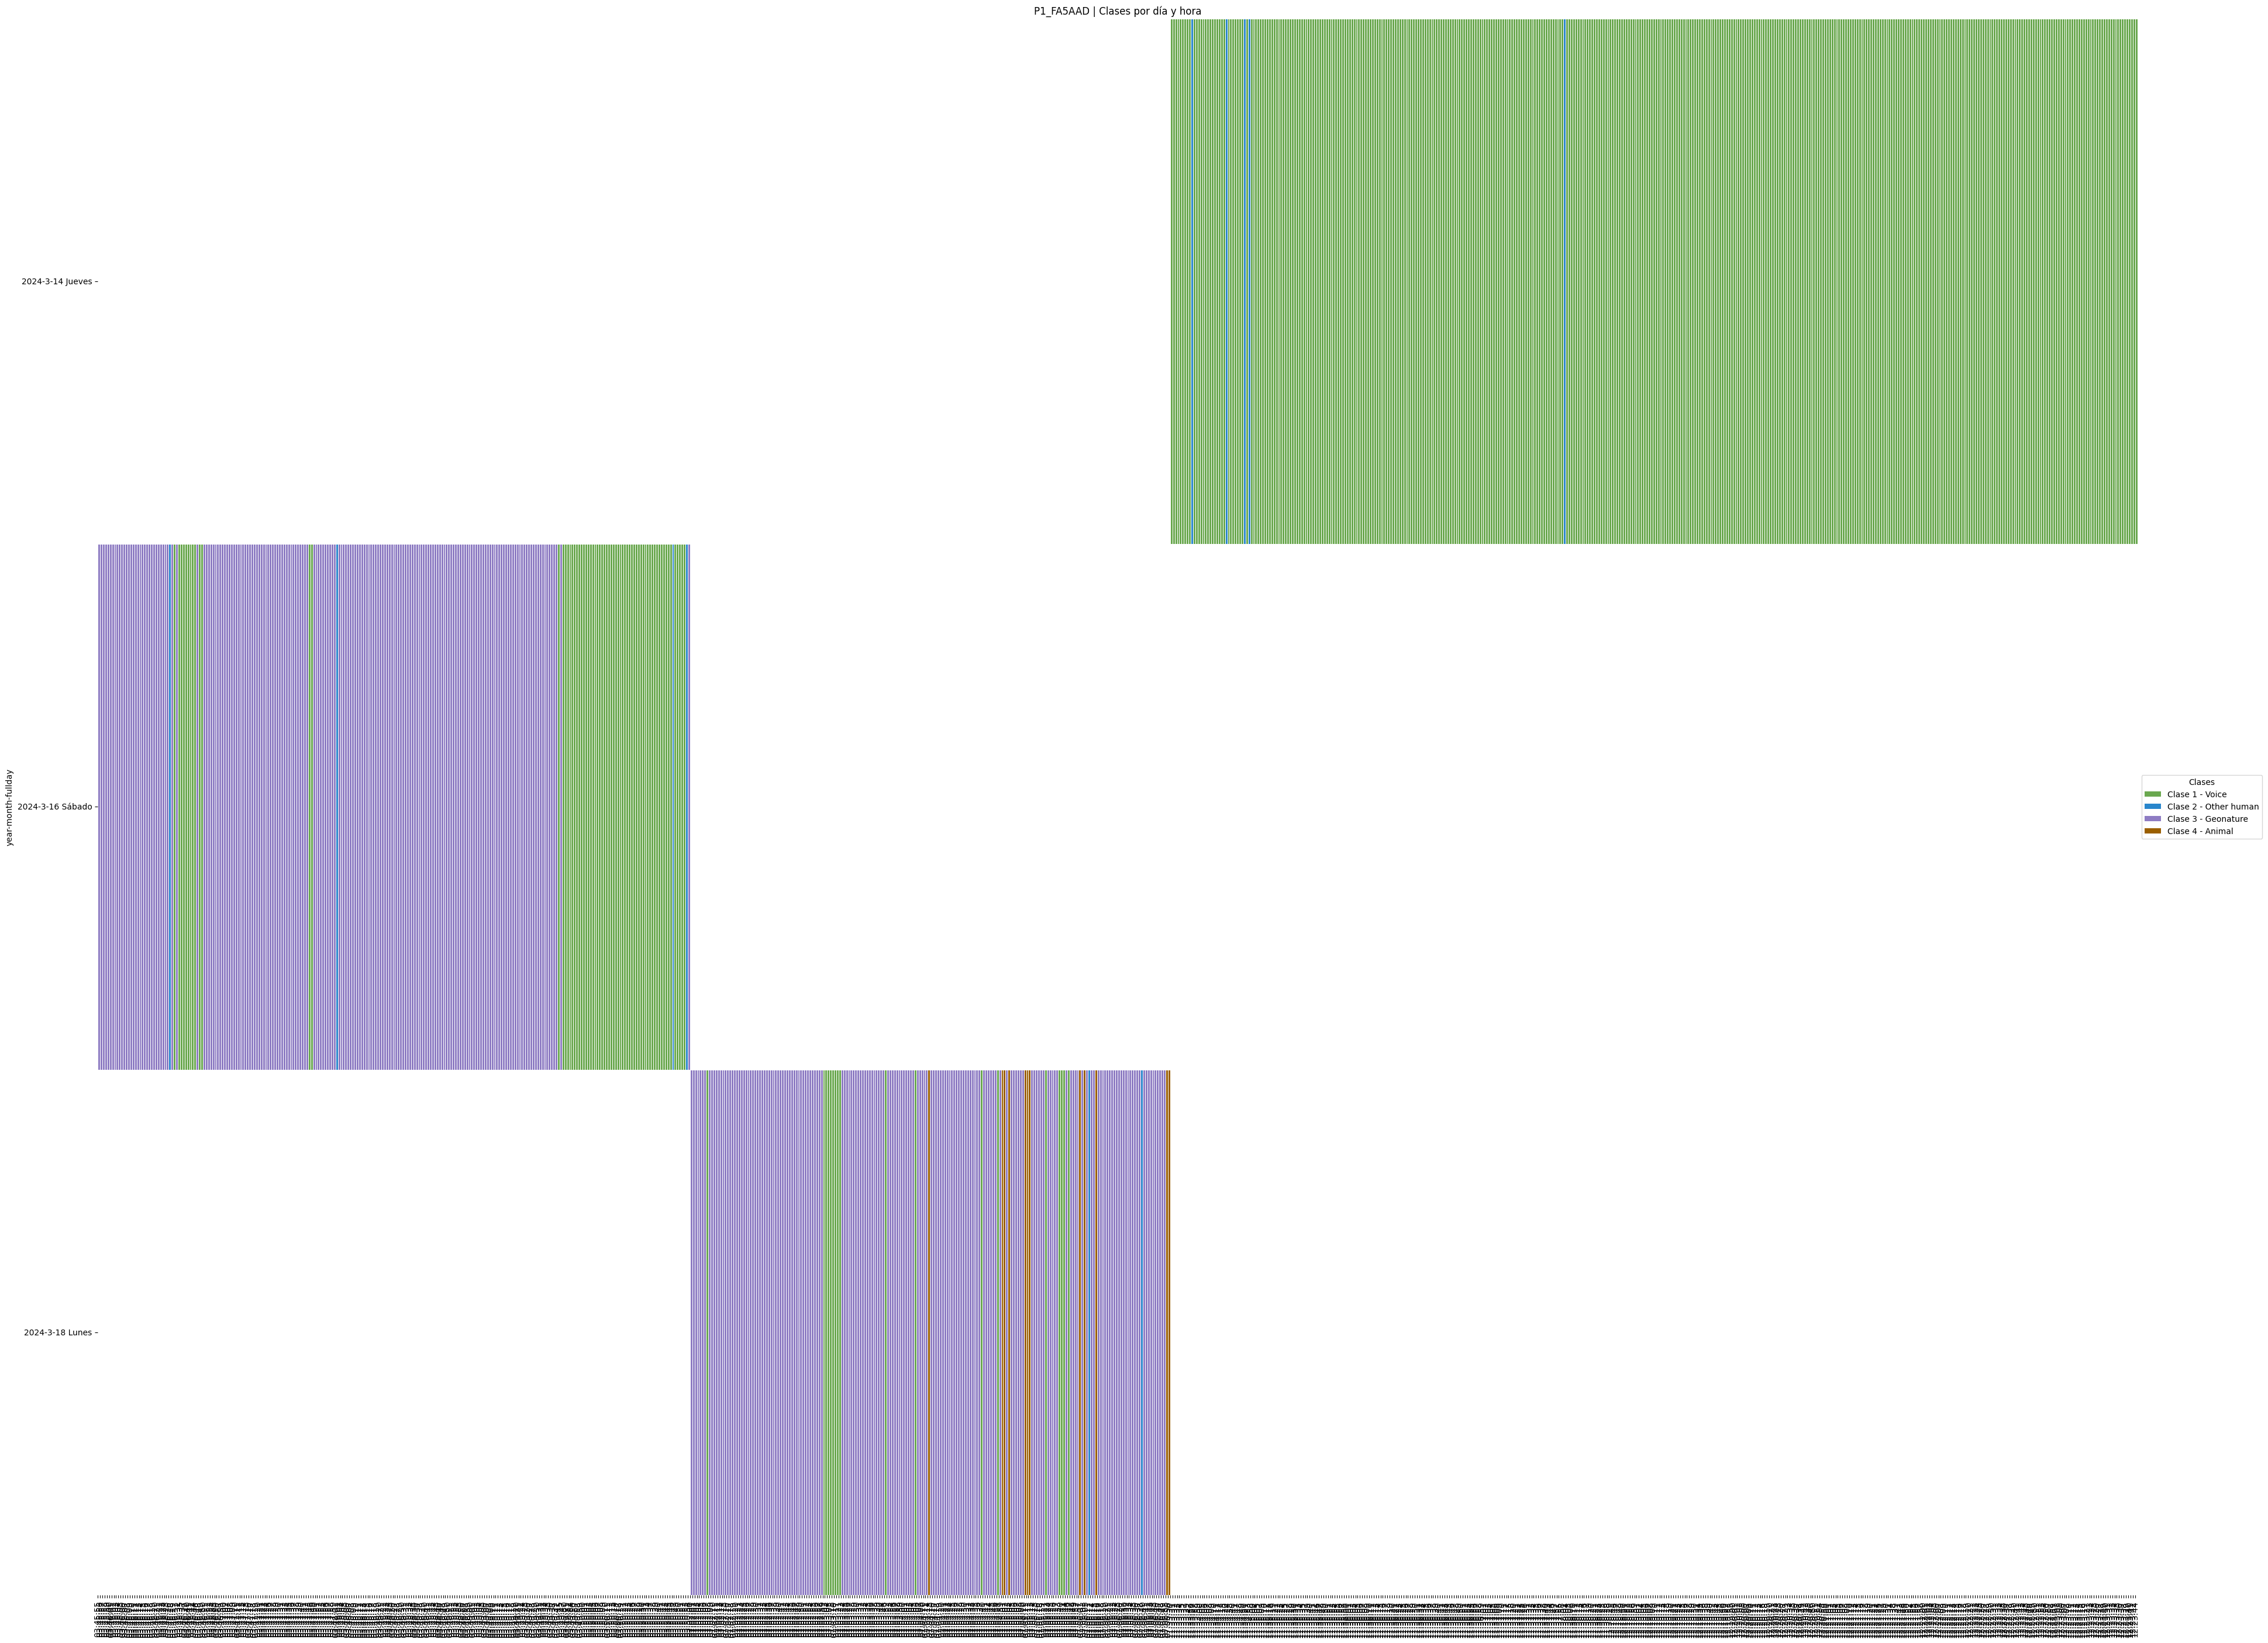

In [33]:
df_exploded = df_exploded.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_exploded['Mapped_Class'].unique())}
df_exploded['class_num'] = df_exploded['Mapped_Class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_exploded, columns=df_exploded.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

# Stack Bar Plotting

In [ ]:
df_explode = df.explode('classes_original')
df_explode

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,day,hour,minute,second,weekday,fullday,class_num
datetime,,,,,,,,,,,,,,,,,
2024-01-22 12:24:00,20240122_122400.WAV,"[Animal, Geonature, Other Sounds]",[0.20753266 0.20753266 0.14310026],0.558166,Silence,"[0.305073, 0.10176207, 0.09112301]",0.497958,Animal,2024,1,22,12,24,0,Lunes,22 Lunes,1
2024-01-22 12:24:00,20240122_122400.WAV,"[Animal, Geonature, Other Sounds]",[0.20753266 0.20753266 0.14310026],0.558166,"Inside, small room","[0.305073, 0.10176207, 0.09112301]",0.497958,Animal,2024,1,22,12,24,0,Lunes,22 Lunes,1
2024-01-22 12:24:00,20240122_122400.WAV,"[Animal, Geonature, Other Sounds]",[0.20753266 0.20753266 0.14310026],0.558166,Snake,"[0.305073, 0.10176207, 0.09112301]",0.497958,Animal,2024,1,22,12,24,0,Lunes,22 Lunes,1
2024-01-22 12:24:20,20240122_122420.WAV,"[Animal, Background, Other Sounds]",[0.12582204 0.12582204 0.11978282],0.371427,Animal,"[0.1328402, 0.12331028, 0.070399344]",0.326550,Animal,2024,1,22,12,24,20,Lunes,22 Lunes,1
2024-01-22 12:24:20,20240122_122420.WAV,"[Animal, Background, Other Sounds]",[0.12582204 0.12582204 0.11978282],0.371427,"Outside, rural or natural","[0.1328402, 0.12331028, 0.070399344]",0.326550,Animal,2024,1,22,12,24,20,Lunes,22 Lunes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-27 15:41:40,20240127_154140.WAV,"[Animal, Background, Other Sounds]",[0.24884313 0.24884313 0.19113643],0.688823,Animal,"[0.26928696, 0.17893085, 0.17414267]",0.622360,Animal,2024,1,27,15,41,40,Sábado,27 Sábado,1
2024-01-27 15:41:40,20240127_154140.WAV,"[Animal, Background, Other Sounds]",[0.24884313 0.24884313 0.19113643],0.688823,Silence,"[0.26928696, 0.17893085, 0.17414267]",0.622360,Animal,2024,1,27,15,41,40,Sábado,27 Sábado,1
2024-01-27 15:42:40,20240127_154240.WAV,"[Animal, Background, Other Sounds]",[0.27125228 0.27125228 0.14752096],0.690026,Environmental noise,"[0.2865773, 0.18154475, 0.18113115]",0.649253,Animal,2024,1,27,15,42,40,Sábado,27 Sábado,1


In [ ]:
df_explode['display_name'] = df_explode['classes_original']

# read ontology union file
union = pd.read_csv(r"C:\Users\GIS2\Documents\santi\GitHub\AAC\AI_Model\Urban_Model\taxonomy_mapping\yamnet_class_AAC_v1_0.csv",sep=';')

# merge classes with ontology
df_explode = df_explode.merge(
    union,
    how='left',
    on='display_name'
    )


# remove columns
df_explode = df_explode.drop(columns=['Brown_Level_1', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'classes_custom', 'probabilities_custom', 'sum_probs_custom', 'sum_probs_original'])
df_explode

,files,classes_original,probabilities_original,single_class,year,month,day,hour,minute,second,weekday,fullday,class_num,display_name,index,mid,iso_taxonomy,Brown_Level_2,Brown_Level_3
0,20240122_122400.WAV,Silence,"[0.305073, 0.10176207, 0.09112301]",Animal,2024,1,22,12,24,0,Lunes,22 Lunes,1,Silence,494,/m/028v0c,Fx,Geonature,Silence
1,20240122_122400.WAV,"Inside, small room","[0.305073, 0.10176207, 0.09112301]",Animal,2024,1,22,12,24,0,Lunes,22 Lunes,1,"Inside, small room",500,/t/dd00125,Background,Background,Background people
2,20240122_122400.WAV,Snake,"[0.305073, 0.10176207, 0.09112301]",Animal,2024,1,22,12,24,0,Lunes,22 Lunes,1,Snake,129,/m/078jl,Wildlife,Animal,wildlife
3,20240122_122420.WAV,Animal,"[0.1328402, 0.12331028, 0.070399344]",Animal,2024,1,22,12,24,20,Lunes,22 Lunes,1,Animal,67,/m/0jbk,Nature,Animal,Animal
4,20240122_122420.WAV,"Outside, rural or natural","[0.1328402, 0.12331028, 0.070399344]",Animal,2024,1,22,12,24,20,Lunes,22 Lunes,1,"Outside, rural or natural",504,/t/dd00129,Background,Background,Background Env
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62935,20240127_154140.WAV,Animal,"[0.26928696, 0.17893085, 0.17414267]",Animal,2024,1,27,15,41,40,Sábado,27 Sábado,1,Animal,67,/m/0jbk,Nature,Animal,Animal
62936,20240127_154140.WAV,Silence,"[0.26928696, 0.17893085, 0.17414267]",Animal,2024,1,27,15,41,40,Sábado,27 Sábado,1,Silence,494,/m/028v0c,Fx,Geonature,Silence
62937,20240127_154240.WAV,Environmental noise,"[0.2865773, 0.18154475, 0.18113115]",Animal,2024,1,27,15,42,40,Sábado,27 Sábado,1,Environmental noise,508,/m/06_y0by,Background,Background,Background Env
62938,20240127_154240.WAV,Animal,"[0.2865773, 0.18154475, 0.18113115]",Animal,2024,1,27,15,42,40,Sábado,27 Sábado,1,Animal,67,/m/0jbk,Nature,Animal,Animal


In [ ]:
# rename columns
df_explode.rename(columns={"fullday": "Día", "hour": "Hora", "mid": "Distribución de clases"}, inplace=True)
unique_día_weekday = df_explode['Día'].unique()

df_explode['Día'] = pd.Categorical(df_explode['Día'], categories=unique_día_weekday, ordered=True)
df_explode.columns

Index(['files', 'classes_original', 'probabilities_original', 'single_class',
       'year', 'month', 'day', 'Hora', 'minute', 'second', 'weekday', 'Día',
       'class_num', 'display_name', 'index', 'Distribución de clases',
       'iso_taxonomy', 'Brown_Level_2', 'Brown_Level_3'],
      dtype='object')

In [ ]:
dfg = df_explode.groupby(['Brown_Level_2','Día']).count().reset_index()

fig = px.bar(
    dfg, 
    x='Día',
    y='Distribución de clases',
    color='Brown_Level_2',
    title=f'{title} | Clases por día',
    color_discrete_sequence=px.colors.qualitative.Alphabet, 
    color_discrete_map=COLLOR_PALLET,
    height=900,
    width=2000
)

fig.show()

# save plot
fig.write_image(f"{visualization_dir}/{title}_classes_per_day_{stable_version}.png")
print(f"Image was saved in {visualization_dir}/{title}_classes_per_day_{stable_version}.png")

Image was saved in //192.168.205.117/AAC_Server/INDUSTRIA/23132-IRUÑA_OCA_CANTERA/5-Resultados/FBD3A7-FAA212-P2_CAMPAÑA1/URBAN_Model/Visualizations/FBD3A7-FAA212_classes_per_day_v1_0.png


# 15 minutes resamply

In [ ]:
# resample the df_15 to get one row for each 15 minutes without missing columns
df_15 = df.resample("15T").mean()
# remove class_num column
# df_15.drop(columns=["class_num"], inplace=True)
df_15

,sum_probs_custom,sum_probs_original,year,month,hour,minute,second,class_num
datetime,,,,,,,,
2024-01-22 12:15:00,0.482746,0.400094,2024.0,1.0,12.0,26.500000,20.000000,2.166667
2024-01-22 12:30:00,0.536084,0.430475,2024.0,1.0,12.0,37.000000,20.000000,2.155556
2024-01-22 12:45:00,0.510472,0.419819,2024.0,1.0,12.0,52.000000,20.000000,2.666667
2024-01-22 13:00:00,0.509150,0.484509,2024.0,1.0,13.0,7.000000,20.000000,2.333333
2024-01-22 13:15:00,0.548797,0.388088,2024.0,1.0,13.0,22.000000,20.000000,2.022222
...,...,...,...,...,...,...,...,...
2024-01-27 14:30:00,0.507172,0.358691,2024.0,1.0,14.0,37.000000,24.000000,1.688889
2024-01-27 14:45:00,0.535232,0.384410,2024.0,1.0,14.0,52.000000,24.000000,1.355556
2024-01-27 15:00:00,0.533958,0.421177,2024.0,1.0,15.0,6.891892,25.081081,1.513514


In [ ]:
# Separate numerical and categorical columns
numerical_cols = ['sum_probs_custom', 'sum_probs_original', 'year', 'month', 'hour', 'minute', 'second']
categorical_cols = ['single_class']

# Resample numerical columns
df_numerical = df[numerical_cols].resample('5T').mean()

# Resample categorical columns
df_categorical = df[categorical_cols].resample('5T').agg(lambda x: x.value_counts().index[0] if not x.empty else None)

# Merge the resampled data
df_resampled = pd.concat([df_numerical, df_categorical], axis=1)

# Reapply the mapping to categorical data
class_to_num = {class_name: index + 1 for index, class_name in enumerate(df['single_class'].unique())}
df_resampled['class_num'] = df_resampled['single_class'].map(class_to_num)

# remove nan values
df_resampled = df_resampled.dropna()
df_resampled = insert_dates(df_resampled)
df_resampled

,sum_probs_custom,sum_probs_original,year,month,hour,minute,second,single_class,class_num,day,weekday,fullday
datetime,,,,,,,,,,,,
2024-01-22 12:20:00,0.456313,0.390632,2024,1,12,20,0,Animal,1.0,22,Lunes,22 Lunes
2024-01-22 12:25:00,0.488033,0.401987,2024,1,12,25,0,Motorised transport,2.0,22,Lunes,22 Lunes
2024-01-22 12:30:00,0.511859,0.493730,2024,1,12,30,0,Motorised transport,2.0,22,Lunes,22 Lunes
2024-01-22 12:35:00,0.556183,0.464133,2024,1,12,35,0,Motorised transport,2.0,22,Lunes,22 Lunes
2024-01-22 12:40:00,0.540209,0.333563,2024,1,12,40,0,Motorised transport,2.0,22,Lunes,22 Lunes
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-27 15:20:00,0.579221,0.499496,2024,1,15,20,0,Animal,1.0,27,Sábado,27 Sábado
2024-01-27 15:25:00,0.632560,0.590367,2024,1,15,25,0,Animal,1.0,27,Sábado,27 Sábado
2024-01-27 15:30:00,0.589519,0.498468,2024,1,15,30,0,Animal,1.0,27,Sábado,27 Sábado


Saved image at //192.168.205.117/AAC_Server/INDUSTRIA/23132-IRUÑA_OCA_CANTERA/5-Resultados/FBD3A7-FAA212-P2_CAMPAÑA1/URBAN_Model/Visualizations/FBD3A7-FAA212_predictions_map_v1_0.png


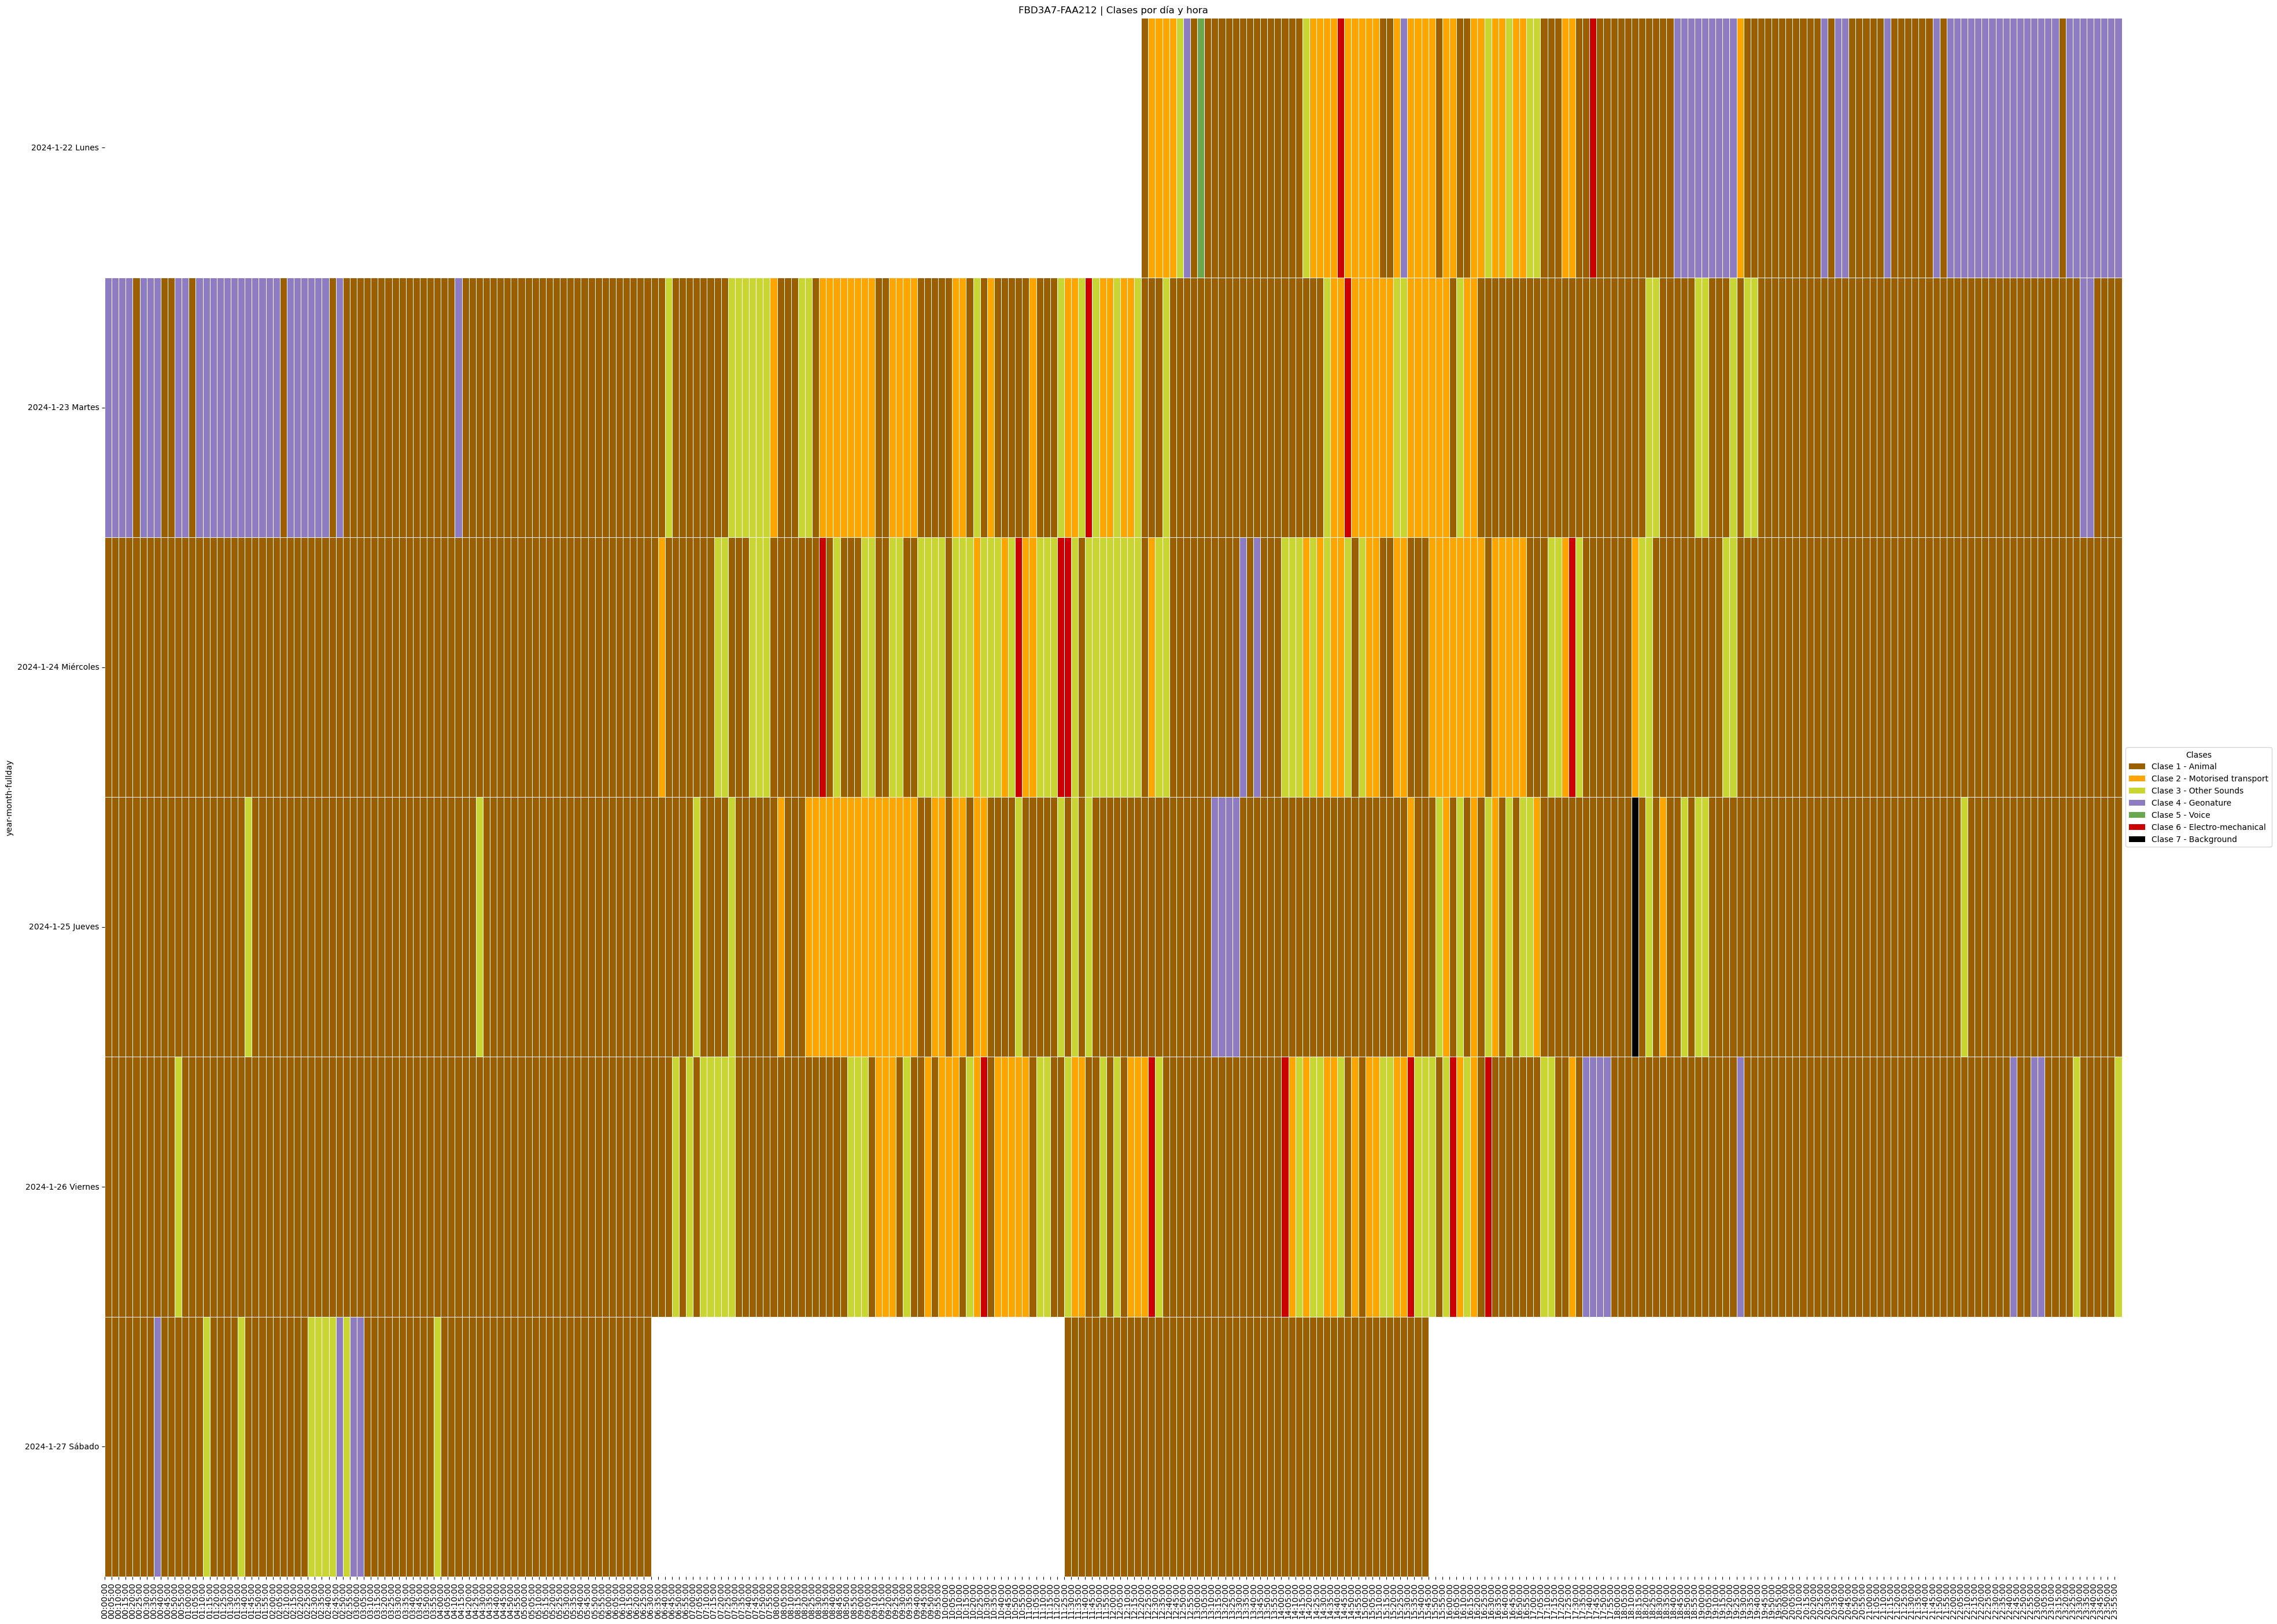

In [ ]:
df_resampled = df_resampled.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_resampled['single_class'].unique())}
df_resampled['class_num'] = df_resampled['single_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_resampled, columns=df_resampled.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

In [ ]:
day = "19"

# filter for the specific day across all years and months
df_xth = df[df["fullday"].str.startswith(day)]

if df_xth.empty:
    print(f"No data for the {day}th day across all years and months. Skipping...")

else:
    plt.figure(figsize=(20, 10))
    
    # pivot is used to get the heatmap | aggfunc is used to get the mode of the classes for each time
    day_class = pd.pivot_table(data=df_xth, columns=df_xth.index.time, index=["year", "month"], values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
    
    if day_class.isna().all().all() or day_class.empty:
        print(f"No valid data for the {day}th day. Skipping...")

    else:
        # unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # setup the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        
        # Hide the y-axis labels (to remove year and month labels)
        ax.yaxis.set_visible(False)
        
        # include the years and months in the dataset
        years = "-".join(map(str, sorted(df_xth["year"].unique())))
        months = "-".join(map(str, sorted(df_xth["month"].unique())))

        # legend
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {years}-{months}-{day}")

        plt.show()

No data for the 19th day across all years and months. Skipping...


In [ ]:
day = "19"

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    for month in sorted(df_year["month"].unique()):
        df_temp = df_year[df_year["month"] == month]
        
        df_xth = df_temp[df_temp["fullday"].str.startswith(day)]
        
        start_time = pd.to_datetime("17:18:00").time()
        end_time = pd.to_datetime("18:04:00").time()
        time_mask = (df_xth.index.time >= start_time) & (df_xth.index.time <= end_time)
        df_xth_filtered = df_xth[time_mask]
        
        if df_xth_filtered.empty:
            print(f"No data for the {day}th day in Year: {year}, Month: {month} within the specified time range. Skipping...")
            continue
        
        plt.figure(figsize=(18, 10))
        
        day_class = pd.pivot_table(data=df_xth_filtered, columns=df_xth_filtered.index.time, index="fullday", values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
        
        if day_class.isna().all().all() or day_class.empty:
            print(f"No valid data for Year: {year}, Month: {month}, Day: {day} within the specified time range. Skipping...")
            continue
        
        # Get unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Create a list of colors in the order of class numbers
        cmap = [num_to_color[int(cls_num)] for cls_num in unique_classes if cls_num in name_class]

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=num_to_color[int(cls_num)], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # Create the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Completely hide the y-axis
        ax.yaxis.set_visible(False)
        
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {year}-{month}-{day} within {start_time.strftime('%H:%M:%S')} to {end_time.strftime('%H:%M:%S')}")

        plt.show()

No data for the 19th day in Year: 2024, Month: 1 within the specified time range. Skipping...
